# TANZANIAN'S WATER WELLS PREDICTION PROJECT

## Table of Contents
1. [Overview](#1-overview)
2. [Modeling](#2-modeling)
3. [Evaluation and Recommendation](#3-evaluation-and-recommendation)



# 1. Overview

## 1.1 Business Understanding

Water Wells for Africa (WWFA) is a non-governmental organization committed to ensuring sustainable access to clean and safe water across rural and underserved communities in Africa. With a mission to bridge the water access gap, WWFA works closely with local governments, community leaders, and international partners to maintain and restore water infrastructure across the country.

### 1.1.1 Business Problem

Tanzania, a developing nation with a population of over 57 million people, faces a critical water access crisis. While thousands of water points have been established across the country, a significant number are either non-functional or in need of repair, leaving millions of citizens without reliable access to clean water.
Currently, identifying which water pumps need attention relies heavily on manual field inspections, which are costly, time-consuming, and inefficient. By the time a faulty pump is identified and repaired, communities may have gone weeks or months without clean water, leading to serious public health consequences.

My role as a data scientist at WWFA is to analyze historical water points across Tanzania and dentify patterns of the non-functional wells that are contributing to water shortage such as pump failure,geo-location, pump type and hwo they are managed. These insights will help in coming up with recommendations to improve water wells for long-term basis.. Lastely by laveraging these patterns I will be able to build a predictive classifiation model  that will ccurately identify existing water points that are non-functional or in need of repair , ensuring that field teams can intervene quickly and efficiently, and that the people of Tanzania have reliable access to clean, potable water.

### 1.1.2 Objectives

1. To identify the key drivers of water point failures in Tanzania.

2. To identify the functional and non-functional water points and build a predictive classification model based on the available variables.

3. To come up with actionable insights for the future water point constructions in Tanzania.

### 1.1.3 Reasearch Questions 

1. What are the key drivers of water point failures in Tanzania?

2. Which water points are functional and non-functional, and can a predictive classification model be built based on the available variables?

3. What actionable insights can be drawn to guide future water point constructions in Tanzania?


### 1.1.4 Success Metrics

1. Successfully identify and rank the top features contributing to water point failure through feature importance analysis and exploratory data analysis.
   
2. Successfully build a Predictive Classification Model that will be able to predict  and improve water well stituation in Tanzania with an accuracy of at least  80%.

   
3. To successfully come up with guides for future water point constructions in Tanzania

## 1.2 Data Understanding

Data Understanding helps us know where the data came from and how they relate to the data anaysis questions It helps us know what and who is in the data presented, and the properties of the variables to be used

### 1.2.1 Importing necessary libraries:

In [1]:
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.model_selection import ShuffleSplit, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso, LinearRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)

### 1.2.2 Loading and Merging the 3 Dataset

In [2]:
# Load the data into pandas DataFrame
train = pd.read_csv('water_well_1.csv')                      
labels = pd.read_csv('train_label_1.csv') 
test = pd.read_csv('water_well_2.csv')                           

# Merge to get full training dataset
df = train.merge(labels, on='id')
print(df.shape)

(59400, 41)


The dataset consists of 41 columns and 59400 rows.

### 1.2.3 Peviewing the Data

In [3]:
# Preview the DataFrame
df.head(5)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [4]:
# Describe the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [5]:
# Checking the numerical and categorical columns

# Numerical Columns
print(f"Numerical Columns: {df.select_dtypes(include='number').columns.tolist()}\n")

# Categorical Columns
print(f"Categorical Columns: {df.select_dtypes(include='object').columns.tolist()}") 

Numerical Columns: ['id', 'amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private', 'region_code', 'district_code', 'population', 'construction_year']

Categorical Columns: ['date_recorded', 'funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


In [6]:
# Describe the  data
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


## 1.3 Data Preparation

Data preparation purpose is to clean the data, select necessary columns, and conduct Exploratory Data Anaysis in order to have clean data for modelling and accuracy

In [7]:
#preview data again
df

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,2013-05-03,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,Pangani,Kiduruni,Kilimanjaro,3,5,Hai,Masama Magharibi,125,True,GeoData Consultants Ltd,Water Board,Losaa Kia water supply,True,1999,gravity,gravity,gravity,water board,user-group,pay per bucket,per bucket,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
59396,27263,4700.0,2011-05-07,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,Rufiji,Igumbilo,Iringa,11,4,Njombe,Ikondo,56,True,GeoData Consultants Ltd,VWC,Ikondo electrical water sch,True,1996,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional
59397,37057,0.0,2011-04-11,NaN,0,NaN,34.017087,-8.750434,Mashine,0,Rufiji,Madungulu,Mbeya,12,7,Mbarali,Chimala,0,True,GeoData Consultants Ltd,VWC,NaN,False,0,swn 80,swn 80,handpump,vwc,user-group,pay monthly,monthly,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional
59398,31282,0.0,2011-03-08,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,Rufiji,Mwinyi,Dodoma,1,4,Chamwino,Mvumi Makulu,0,True,GeoData Consultants Ltd,VWC,NaN,True,0,nira/tanira,nira/tanira,handpump,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional


### 1.3.1 Checking related columns

Since many of the 41 columns in the dataset appear to be interrelated, I will start by examining the correlated variables before proceeding to analyze the remaining columns.

#### 3.1.1.1 Related column 1(scheme management, management, management_group)

In [8]:
# checking unique values in scheme_management column
df['scheme_management'].value_counts(dropna=False)

scheme_management
VWC                 36793
WUG                  5206
NaN                  3878
Water authority      3153
WUA                  2883
Water Board          2748
Parastatal           1680
Private operator     1063
Company              1061
Other                 766
SWC                    97
Trust                  72
Name: count, dtype: int64

In [9]:
# checking unique values in management column
df['management'].value_counts(dropna=False)

management
vwc                 40507
wug                  6515
water board          2933
wua                  2535
private operator     1971
parastatal           1768
water authority       904
other                 844
company               685
unknown               561
other - school         99
trust                  78
Name: count, dtype: int64

In [10]:
# checking unique values in management_group column
df['management_group'].value_counts(dropna=False)

management_group
user-group    52490
commercial     3638
parastatal     1768
other           943
unknown         561
Name: count, dtype: int64

from the preview on checking related columns scheme_management and management seems to be related as for management_group  appears to have fewer unique values to the 2.. In order to understand how the two now relate I will perform a group by to examint their relationship

In [11]:
# Group by management_group only since management column has already been dropped in next cell to avoid errors
summary = (
    df.groupby(['management_group'])
    .agg(
        count=('management_group', 'size'),
        percentage=('management_group', lambda x: round((len(x) / len(df)) * 100, 2))
    )
    .rename_axis(['Management Group'])
    .sort_values(by='count', ascending=False)
)

# Add a cumulative percentage column
summary['cumulative_%'] = summary['percentage'].cumsum().round(2)

# Display the result
summary.style.background_gradient(cmap='Blues', subset=['count', 'percentage'])

,count,percentage,cumulative_%
Management Group,,,
user-group,52490,88.370000,88.370000
commercial,3638,6.120000,94.490000
parastatal,1768,2.980000,97.470000
other,943,1.590000,99.060000
unknown,561,0.940000,100.000000


From the output, I can observe a clear relationship between the management_group and management columns. However, since management_group contains fewer unique values than management, I will drop the management column to avoid model complexity.

In [12]:
# dropping the management column
# Drop the management and scheme_management columns if they exist
df = df.drop(['scheme_management', 'management'], axis=1, errors='ignore')

# Confirm the columns have been dropped
print(df.columns.tolist())

['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'recorded_by', 'scheme_name', 'permit', 'construction_year', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


#### 1.3.1.2 Related column 2(payment, payment type)


In [13]:
# checking unique values in payment column
df['payment'].value_counts(dropna=False)

payment
never pay                25348
pay per bucket            8985
pay monthly               8300
unknown                   8157
pay when scheme fails     3914
pay annually              3642
other                     1054
Name: count, dtype: int64

In [14]:
# checking unique values in the payment_type column
df['payment_type'].value_counts(dropna=False)

payment_type
never pay     25348
per bucket     8985
monthly        8300
unknown        8157
on failure     3914
annually       3642
other          1054
Name: count, dtype: int64

the two are not much related I will drop payment column

In [15]:
# dropping the Payment column
df = df.drop(['payment'], axis=1, errors='ignore')

#### 1.3.1.3 Related column 2(extraction_type_class,extraction_type_group,extraction_type)


In [16]:
# checking unique values in extraction_type_class column
df['extraction_type_class'].value_counts(dropna=False) 

extraction_type_class
gravity         26780
handpump        16456
other            6430
submersible      6179
motorpump        2987
rope pump         451
wind-powered      117
Name: count, dtype: int64

In [17]:
# checking unique values in extraction_type_group column
df['extraction_type_group'].value_counts(dropna=False)

extraction_type_group
gravity            26780
nira/tanira         8154
other               6430
submersible         6179
swn 80              3670
mono                2865
india mark ii       2400
afridev             1770
rope pump            451
other handpump       364
other motorpump      122
wind-powered         117
india mark iii        98
Name: count, dtype: int64

In [18]:
# checking unique values in extraction_type column
df['extraction_type'].value_counts(dropna=False)

extraction_type
gravity                      26780
nira/tanira                   8154
other                         6430
submersible                   4764
swn 80                        3670
mono                          2865
india mark ii                 2400
afridev                       1770
ksb                           1415
other - rope pump              451
other - swn 81                 229
windmill                       117
india mark iii                  98
cemo                            90
other - play pump               85
walimi                          48
climax                          32
other - mkulima/shinyanga        2
Name: count, dtype: int64

extraction_type and extraction_type_group are related while extraction_type_class is not related to the two.

In [19]:
# Group by extraction_type_class, extraction_type_group, and extraction_type with aggregated statistics
summary = (
    df.groupby(['extraction_type_class', 'extraction_type_group', 'extraction_type'])
    .agg(
        count=('extraction_type', 'size'),
        percentage=('extraction_type', lambda x: round((len(x) / len(df)) * 100, 2))
    )
    .rename_axis(['Extraction Type Class', 'Extraction Type Group', 'Extraction Type'])
    .sort_values(by='count', ascending=False)
)

# Add a cumulative percentage column
summary['cumulative_%'] = summary['percentage'].cumsum().round(2)

# Display the result with styling
summary.style.background_gradient(cmap='Blues', subset=['count', 'percentage', 'cumulative_%'])

Extraction_type_group seems nore detalied, I will drop extraction_type_class and extraction_type clolumns

In [20]:
# Droping the extraction_type_class and extraction_type columns
df=df.drop(['extraction_type_class', 'extraction_type'], axis=1, errors='ignore')

#### 3.1.1.4 Related column 4(Quality and Quantity group)

In [21]:
# checking unique values in Quality column
df['quantity'].value_counts(dropna=False)

quantity
enough          33186
insufficient    15129
dry              6246
seasonal         4050
unknown           789
Name: count, dtype: int64

In [22]:
# checking unique values in Quality column
df['quantity_group'].value_counts(dropna=False)

quantity_group
enough          33186
insufficient    15129
dry              6246
seasonal         4050
unknown           789
Name: count, dtype: int64

The two are perfectly correlated will proceed to drop one,'quantity group'

In [23]:
# Dropping the quantity_group column

df = df.drop(['quantity_group'], axis=1, errors='ignore')

#### 3.1.1.5 Related column 5(waterpoint_type, waterpoint_type_group)

In [24]:
# checking unique values in waterpoint_type column
df['waterpoint_type'].value_counts(dropna=False)

waterpoint_type
communal standpipe             28522
hand pump                      17488
other                           6380
communal standpipe multiple     6103
improved spring                  784
cattle trough                    116
dam                                7
Name: count, dtype: int64

In [25]:
# checking unique values in waterpoint_type_group column
df['waterpoint_type_group'].value_counts(dropna=False)

waterpoint_type_group
communal standpipe    34625
hand pump             17488
other                  6380
improved spring         784
cattle trough           116
dam                       7
Name: count, dtype: int64

dropping waterpoint_type_group column has less unique values

In [26]:
# Drop the waterpoint_type_group column
df = df.drop(['waterpoint_type_group'], axis=1, errors='ignore')

#### 3.1.1.6 Related column 6(source_class,source,source_type)

In [27]:
# checking unique values in source column
df['source'].value_counts(dropna=False)

source
spring                  17021
shallow well            16824
machine dbh             11075
river                    9612
rainwater harvesting     2295
hand dtw                  874
lake                      765
dam                       656
other                     212
unknown                    66
Name: count, dtype: int64

In [28]:
# checking unique values in source_class column
df['source_class'].value_counts(dropna=False)

source_class
groundwater    45794
surface        13328
unknown          278
Name: count, dtype: int64

In [29]:
# checking unique values in source_type column
df['source_type'].value_counts(dropna=False)

source_type
spring                  17021
shallow well            16824
borehole                11949
river/lake              10377
rainwater harvesting     2295
dam                       656
other                     278
Name: count, dtype: int64

dropping source,source_class column has less unique values

In [30]:
# Drop the 'source' and 'source_class' columns
df = df.drop(['source', 'source_class'], axis=1, errors='ignore')

#### 1.3.1.5 Dropping all other columns that are not useful

drop all columns that will not help in coming up with the perfect predictive model

In [31]:
# Drop all unnecessary columns
df = df.drop([
    'longitude', 'latitude', 'wpt_name', 'num_private', 
    'region_code', 'district_code', 'public_meeting', 
    'recorded_by', 'scheme_name'
], axis=1, errors='ignore')

# Confirm the columns have been dropped
print(df.columns.tolist())

['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'basin', 'subvillage', 'region', 'lga', 'ward', 'population', 'permit', 'construction_year', 'extraction_type_group', 'management_group', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'source_type', 'waterpoint_type', 'status_group']


## 1.4 Cleaning Data

### 1.4.1.checking missing values and duplicates 

In [32]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

print("\n" + "="*50)

# Check for duplicates
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

Missing Values:
id                          0
amount_tsh                  0
date_recorded               0
funder                   3637
gps_height                  0
installer                3655
basin                       0
subvillage                371
region                      0
lga                         0
ward                        0
population                  0
permit                   3056
construction_year           0
extraction_type_group       0
management_group            0
payment_type                0
water_quality               0
quality_group               0
quantity                    0
source_type                 0
waterpoint_type             0
status_group                0
dtype: int64

Total Missing Values: 10719


Total Duplicate Rows: 0


In [33]:
# 1. Drop duplicate rows
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

# 2. Fill missing values for categorical columns with mode
# funder, installer, subvillage, permit have missing values
cat_cols_with_missing = ['funder', 'installer', 'subvillage', 'permit']
for col in cat_cols_with_missing:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Confirm no missing values remain
print(f"\nRemaining Missing Values: {df.isnull().sum().sum()}")
print(f"\nFinal Shape: {df.shape}")

Shape after dropping duplicates: (59400, 23)

Remaining Missing Values: 0

Final Shape: (59400, 23)


data is clean nomissing  values

In [34]:
# Find the number of duplicated records
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# Display the duplicated records
df[df.duplicated()]

Total Duplicate Rows: 0


,id,amount_tsh,date_recorded,funder,gps_height,installer,basin,subvillage,region,lga,ward,population,permit,construction_year,extraction_type_group,management_group,payment_type,water_quality,quality_group,quantity,source_type,waterpoint_type,status_group


data does not contain duplicates

In [35]:
# feature engineering 
# Extract year and month from date_recorded
df['year_recorded'] = pd.to_datetime(df['date_recorded']).dt.year
df['month_recorded'] = pd.to_datetime(df['date_recorded']).dt.month

# Create age of water point feature
df['waterpoint_age'] = df['year_recorded'] - df['construction_year']

# Drop the date_recorded column as it is no longer needed
df = df.drop(columns=['date_recorded'], errors='ignore')

# Confirm the new features
print(df[['year_recorded', 'month_recorded', 'waterpoint_age']].head())

   year_recorded  month_recorded  waterpoint_age
0           2011               3              12
1           2013               3               3
2           2013               2               4
3           2013               1              27
4           2011               7            2011


### 1.4.2.checking outliers

Outliers are data points that deviate significantly from the rest of the dataset. 
They can arise from various sources, including:

- **Measurement error** — inaccuracies from instruments or tools used during data collection
- **Data entry error** — mistakes made by humans when recording data
- **Changes in system behaviour** — unexpected shifts in how a system operates
- **Fraudulent behaviour** — manipulated or falsified data points
- **Natural deviations** — genuine variations that occur naturally within a population

## Columns for Outlier Treatment

I will perform outlier treatment on the following numerical columns in the dataset:

- `amount_tsh`
- `gps_height`
- `population`
- `construction_year`

## Why Outlier Treatment is Necessary

Outlier treatment is necessary because outliers can:

- Increase error variance and reduce the power of statistical tests
- Decrease normality if they are non-randomly distributed

## Methods for Detecting Outliers

To detect outliers, I will use the following methods:

- **Boxplots** — visually displays the distribution of data and highlights outliers 
as points beyond the whiskers


In [36]:
def outliers(df, col, title):
    """
    This function visualizes outliers using a boxplot.
    
    Parameters:
    -----------
    df  : pandas DataFrame
    col : column to visualize
    title : title of the plot
    """
    # Calculate outlier boundaries
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    # Create a single boxplot
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print outlier summary
    print(f"Lower Bound        : {lower_bound:.2f}")
    print(f"Upper Bound        : {upper_bound:.2f}")
    print(f"Number of Outliers : {outlier_count}")

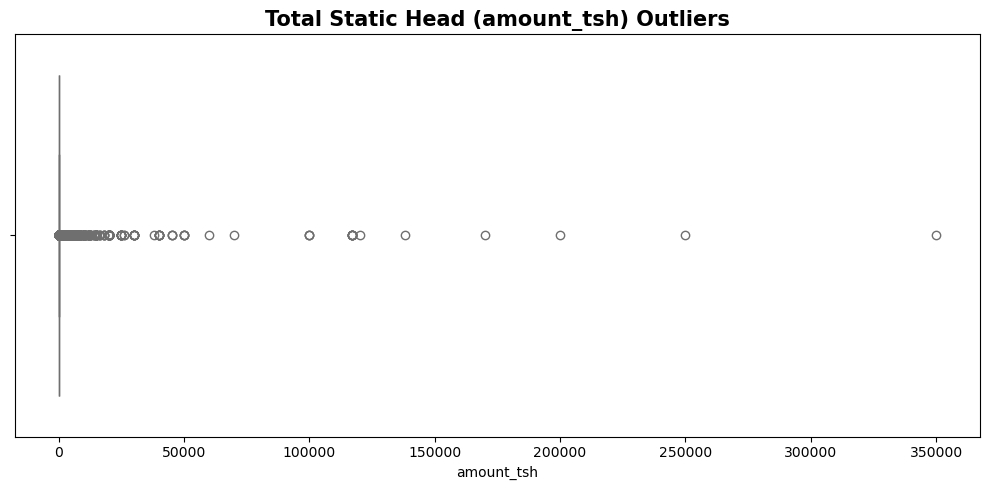

In [37]:
# Visualise the outliers in the amount_tsh column
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['amount_tsh'], color='skyblue')
plt.title('Total Static Head (amount_tsh) Outliers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion: amount_tsh Outliers

From the boxplot, we can observe that the `amount_tsh` column contains extreme 
outliers, with values reaching up to 350,000. The majority of the data is 
concentrated near 0, indicating that the distribution is heavily right-skewed. 

To treat these outliers, we will use the capping (Winsorization) method, which 
replaces the outliers with the upper bound value. This method is preferred because 
it retains all rows in the dataset while reducing the effect of extreme values.

In [38]:
# Calculate the upper bound for amount_tsh
Q1 = df['amount_tsh'].quantile(0.25)
Q3 = df['amount_tsh'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Upper Bound: {upper_bound}")

# Cap the outliers at the upper bound
df['amount_tsh'] = df['amount_tsh'].clip(upper=upper_bound)

# Confirm the capping worked
print(f"Max value after capping: {df['amount_tsh'].max()}")

Upper Bound: 50.0
Max value after capping: 50.0


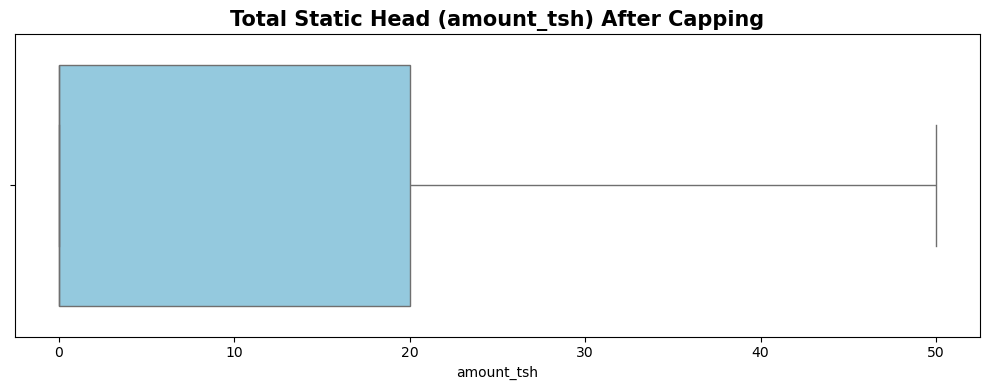

In [39]:
# Visualise the amount_tsh column after capping
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amount_tsh'], color='skyblue')
plt.title('Total Static Head (amount_tsh) After Capping', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

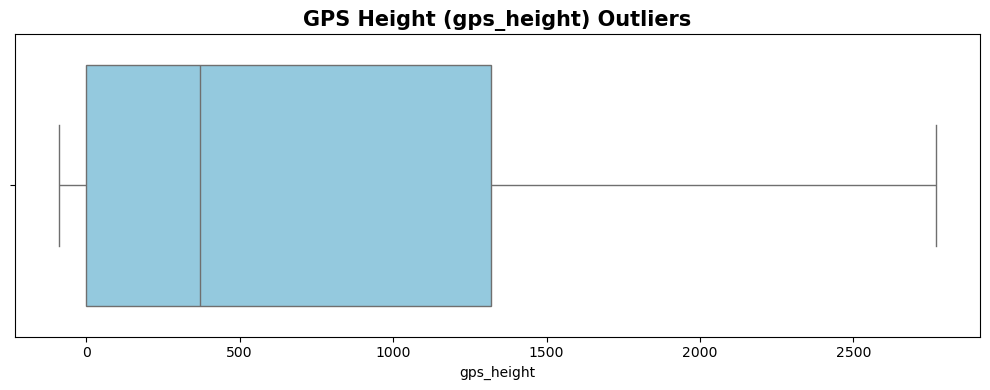

Lower Bound        : -1978.88
Upper Bound        : 3298.12
Number of Outliers : 0


In [40]:
# Visualise the outliers in the gps_height column
outliers(df, 'gps_height', 'GPS Height (gps_height) Outliers')

## Conclusion: gps_height Outliers

From the boxplot, we can observe that the gps_height column contains no outliers. 
Therefore, no outlier treatment is required for this column.

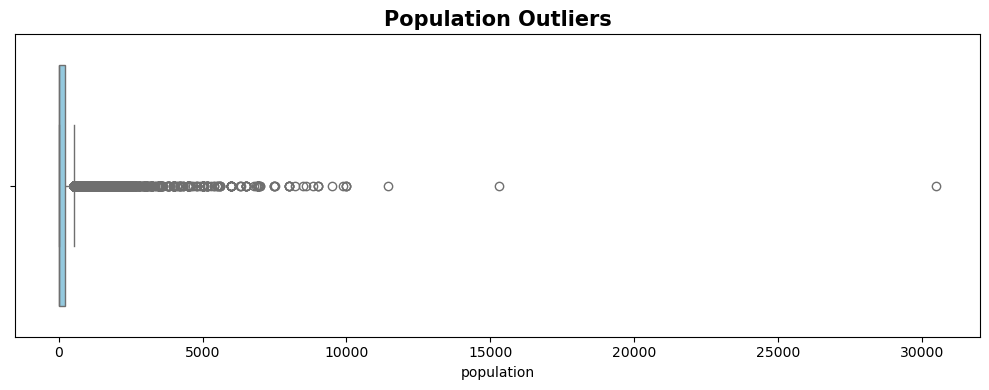

Lower Bound        : -322.50
Upper Bound        : 537.50
Number of Outliers : 4383


In [41]:
# Visualise the outliers in the population column
outliers(df, 'population', 'Population Outliers')

## Conclusion: Population Outliers

The `population` column contains 4383 outliers with values reaching up to 30,000, 
indicating a heavily right-skewed distribution. Additionally, the lower bound is 
negative (-322.50), which is not possible for a population value. 
We will therefore cap the values at the upper bound of 537.50 and set the 
lower bound to 0 to treat these outliers.

In [42]:
# Calculate the upper bound for population
Q1 = df['population'].quantile(0.25)
Q3 = df['population'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Upper Bound: {upper_bound}")

# Cap the outliers at the upper bound
df['population'] = df['population'].clip(lower=0, upper=upper_bound)

# Confirm the capping worked
print(f"Max value after capping: {df['population'].max()}")

Upper Bound: 537.5
Max value after capping: 537.5


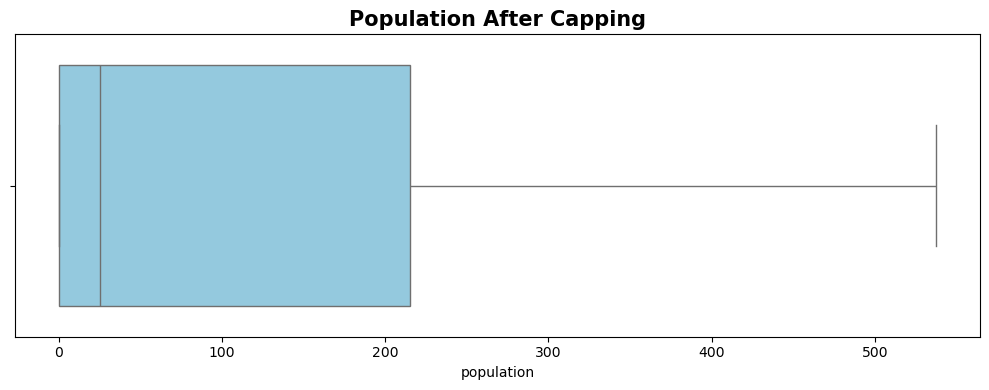

In [43]:
# Visualise the population column after capping
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['population'], color='skyblue')
plt.title('Population After Capping', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

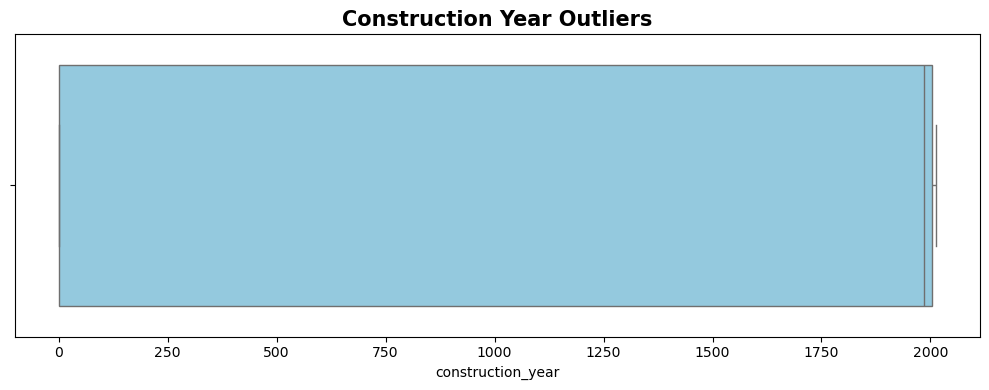

Lower Bound        : -3006.00
Upper Bound        : 5010.00
Number of Outliers : 0


In [44]:
# Visualise the outliers in the construction_year column
outliers(df, 'construction_year', 'Construction Year Outliers')

## Conclusion: Construction Year Outliers

From the boxplot, we can observe that the `construction_year` column contains 
no outliers (0 outliers detected). Therefore, no outlier treatment is required 
for this column.

### 1.4.3.Removing spaces and formatting data

In this section, I will evaluate the consistency of the data by checking whether 
the column names are in lowercase, free of spaces, and interpretable.

In [45]:
def rename_columns(df):
    """
    Reformats column names to lowercase, replaces spaces with underscores,
    and removes special characters.
    """
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace('[^a-z0-9_]', '', regex=True)
                 )
    return df

# Apply the function
df = rename_columns(df)

# Confirm the changes
print(df.columns.tolist())

['id', 'amount_tsh', 'funder', 'gps_height', 'installer', 'basin', 'subvillage', 'region', 'lga', 'ward', 'population', 'permit', 'construction_year', 'extraction_type_group', 'management_group', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'source_type', 'waterpoint_type', 'status_group', 'year_recorded', 'month_recorded', 'waterpoint_age']


In [46]:
# Rename the 'lga' column to 'local_government_area'
df.rename(columns={'lga': 'local_government_area'}, inplace=True)

# Confirm the changes
print(df.columns.tolist())

['id', 'amount_tsh', 'funder', 'gps_height', 'installer', 'basin', 'subvillage', 'region', 'local_government_area', 'ward', 'population', 'permit', 'construction_year', 'extraction_type_group', 'management_group', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'source_type', 'waterpoint_type', 'status_group', 'year_recorded', 'month_recorded', 'waterpoint_age']


In [47]:
def convert_to_category(df):
    """
    Converts all object columns to category data type.
    """
    obj_cols = df.select_dtypes(include='object').columns
    df[obj_cols] = df[obj_cols].astype('category')
    return df

# Apply the function
df = convert_to_category(df)

# Confirm the changes
print(df.dtypes)

id                          int64
amount_tsh                float64
funder                   category
gps_height                  int64
installer                category
basin                    category
subvillage               category
region                   category
local_government_area    category
ward                     category
population                float64
permit                       bool
construction_year           int64
extraction_type_group    category
management_group         category
payment_type             category
water_quality            category
quality_group            category
quantity                 category
source_type              category
waterpoint_type          category
status_group             category
year_recorded               int32
month_recorded              int32
waterpoint_age              int64
dtype: object


In [48]:
print(df.columns.tolist())

['id', 'amount_tsh', 'funder', 'gps_height', 'installer', 'basin', 'subvillage', 'region', 'local_government_area', 'ward', 'population', 'permit', 'construction_year', 'extraction_type_group', 'management_group', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'source_type', 'waterpoint_type', 'status_group', 'year_recorded', 'month_recorded', 'waterpoint_age']


In [49]:
# If there's a whitespace issue, strip all column names
df.columns = df.columns.str.strip()

# If it's a casing issue, lowercase all column names
df.columns = df.columns.str.lower()

# If the column has a different name, rename it first
df = df.rename(columns={'actual_column_name': 'date_recorded'})

In [81]:
df['date_recorded'] = pd.to_datetime({
    'year': df['year_recorded'],
    'month': df['month_recorded'],
    'day': 1
})

In [52]:
# Check the unique values in the installer column
df['installer'].value_counts().head(20)

installer
DWE                   21057
Government             1825
RWE                    1206
Commu                  1060
DANIDA                 1050
KKKT                    898
Hesawa                  840
0                       777
TCRS                    707
Central government      622
CES                     610
Community               553
DANID                   552
District Council        551
HESAWA                  539
LGA                     408
World vision            408
WEDECO                  397
TASAF                   396
District council        392
Name: count, dtype: int64

In [53]:
# Standardize the installer column to lowercase
df['installer'] = df['installer'].str.lower().str.strip()

# Replace inconsistent values
df['installer'] = df['installer'].replace({
    'danid'           : 'danida',
    'commu'           : 'community',
    'hesawa'          : 'hesawa',
    'district council': 'district council',
    'world vision'    : 'world vision',
    '0'               : 'unknown',
    'central government': 'government',
    'lga'             : 'government'
})

# Confirm the changes
df['installer'].value_counts().head(20)

installer
dwe                 21060
government           3067
danida               1674
community            1620
hesawa               1395
rwe                  1206
district council      961
kkkt                  910
unknown               781
tcrs                  707
world vision          699
ces                   610
gover                 511
amref                 443
tasaf                 411
wedeco                398
fini water            389
dmdd                  376
norad                 360
twesa                 316
Name: count, dtype: int64

In [54]:
# Standardize the installer column to lowercase and strip whitespace
df['installer'] = df['installer'].str.lower().str.strip()

# Replace all inconsistent values at once
replace_dict = {
    'district water depar' : 'district water department',
    'distric water department' : 'district water department',
    'fini water' : 'fini water',
    'fini water,' : 'fini water',
    'jaica' : 'jaica',
    'coun' : 'district council',
    'district council' : 'district council',
    'council' : 'district council',
    'rc churc' : 'rc church',
    'rc cathoric' : 'rc church',
    'central government' : 'government',
    'tanzania government' : 'government',
    'world division' : 'world vision',
    'unisef' : 'unicef',
    'danid' : 'danida',
    'commu' : 'community',
    'communit' : 'community',
    '0' : 'unknown'
}

df['installer'] = df['installer'].replace(replace_dict)

# Confirm the changes
df['installer'].value_counts().head(20)

installer
dwe                 21060
government           3101
danida               1674
community            1674
hesawa               1395
rwe                  1206
district council      977
kkkt                  910
unknown               781
tcrs                  707
world vision          701
ces                   610
gover                 511
amref                 443
tasaf                 411
wedeco                398
fini water            389
dmdd                  376
norad                 360
unicef                332
Name: count, dtype: int64

In [55]:
# Standardize the installer column to lowercase and strip whitespace
df['installer'] = df['installer'].str.lower().str.strip()

# Replace all inconsistent values at once
replace_dict = {
    'colonial government'      : 'colonial government',
    'government of misri'      : 'misri government',
    'italy government'         : 'italian government',
    'british colonial government' : 'british government',
    'concern /government'      : 'concern/government',
    'village government'       : 'village government',
    'government and community' : 'government /community',
    'cetral government /rc'    : 'rc church/central government',
    'government /tcrs'         : 'tcrs /government',
    'adra /government'         : 'adra/government',
    'commu'                    : 'community',
    'danid'                    : 'danida',
    '0'                        : 'unknown'
}

df['installer'] = df['installer'].replace(replace_dict)

# Confirm the changes
df['installer'].value_counts().head(20)

installer
dwe                 21060
government           3101
community            1674
danida               1674
hesawa               1395
rwe                  1206
district council      977
kkkt                  910
unknown               781
tcrs                  707
world vision          701
ces                   610
gover                 511
amref                 443
tasaf                 411
wedeco                398
fini water            389
dmdd                  376
norad                 360
unicef                332
Name: count, dtype: int64

In [56]:
df

,id,amount_tsh,funder,gps_height,installer,basin,subvillage,region,local_government_area,ward,population,permit,construction_year,extraction_type_group,management_group,payment_type,water_quality,quality_group,quantity,source_type,waterpoint_type,status_group,year_recorded,month_recorded,waterpoint_age,date_recorded
0,69572,50.0,Roman,1390,roman,Lake Nyasa,Mnyusi B,Iringa,Ludewa,Mundindi,109.0,False,1999,gravity,user-group,annually,soft,good,enough,spring,communal standpipe,functional,2011,3,12,2011-03-01
1,8776,0.0,Grumeti,1399,grumeti,Lake Victoria,Nyamara,Mara,Serengeti,Natta,280.0,True,2010,gravity,user-group,never pay,soft,good,insufficient,rainwater harvesting,communal standpipe,functional,2013,3,3,2013-03-01
2,34310,25.0,Lottery Club,686,world vision,Pangani,Majengo,Manyara,Simanjiro,Ngorika,250.0,True,2009,gravity,user-group,per bucket,soft,good,enough,dam,communal standpipe multiple,functional,2013,2,4,2013-02-01
3,67743,0.0,Unicef,263,unicef,Ruvuma / Southern Coast,Mahakamani,Mtwara,Nanyumbu,Nanyumbu,58.0,True,1986,submersible,user-group,never pay,soft,good,dry,borehole,communal standpipe multiple,non functional,2013,1,27,2013-01-01
4,19728,0.0,Action In A,0,artisan,Lake Victoria,Kyanyamisa,Kagera,Karagwe,Nyakasimbi,0.0,True,0,gravity,other,never pay,soft,good,seasonal,rainwater harvesting,communal standpipe,functional,2011,7,2011,2011-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,Germany Republi,1210,ces,Pangani,Kiduruni,Kilimanjaro,Hai,Masama Magharibi,125.0,True,1999,gravity,user-group,per bucket,soft,good,enough,spring,communal standpipe,functional,2013,5,14,2013-05-01
59396,27263,50.0,Cefa-njombe,1212,cefa,Rufiji,Igumbilo,Iringa,Njombe,Ikondo,56.0,True,1996,gravity,user-group,annually,soft,good,enough,river/lake,communal standpipe,functional,2011,5,15,2011-05-01
59397,37057,0.0,Government Of Tanzania,0,dwe,Rufiji,Madungulu,Mbeya,Mbarali,Chimala,0.0,False,0,swn 80,user-group,monthly,fluoride,fluoride,enough,borehole,hand pump,functional,2011,4,2011,2011-04-01
59398,31282,0.0,Malec,0,musa,Rufiji,Mwinyi,Dodoma,Chamwino,Mvumi Makulu,0.0,True,0,nira/tanira,user-group,never pay,soft,good,insufficient,shallow well,hand pump,functional,2011,3,2011,2011-03-01


In [57]:
# Save the cleaned data to a csv file
df.to_csv('cleaned_data.csv', index=False)

# Confirm the file has been saved
print("Cleaned data saved successfully!")
print(f"Shape of cleaned data: {df.shape}")

Cleaned data saved successfully!
Shape of cleaned data: (59400, 26)


In [82]:
from IPython.display import FileLink

# Save the cleaned data to a csv file
df.to_csv('cleaned_data.csv', index=False)

# Create a download link
FileLink('cleaned_data.csv')

C:\Users\Admin\Documents\flatiron\flatiron\PHASE_3\PHASE_3_PROJECT\cleaned_data.csv

## 1.5 Exploratory Data Analysis

In this section, I will explore the dataset columns through Univariate, Bivariate, and Multivariate analysis 
For the Univariate Analysis, we examine each column individually to understand the distribution of features 
and uncover useful insights, covering both Categorical and Numerical columns.

### 1.5.1 View categorical columns

In [59]:
# View categorical columns
cat_cols = df.select_dtypes(include='category').columns
print("Categorical Columns:")
print(cat_cols.tolist())
print(f"Total Categorical Columns: {len(cat_cols)}")

print("\n" + "="*50)

Categorical Columns:
['funder', 'basin', 'subvillage', 'region', 'local_government_area', 'ward', 'extraction_type_group', 'management_group', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'source_type', 'waterpoint_type', 'status_group']
Total Categorical Columns: 15



### 1.5.2 View numerical columns

In [60]:
# View numerical columns
num_cols = df.select_dtypes(include='number').columns
print("\nNumerical Columns:")
print(num_cols.tolist())
print(f"Total Numerical Columns: {len(num_cols)}")


Numerical Columns:
['id', 'amount_tsh', 'gps_height', 'population', 'construction_year', 'year_recorded', 'month_recorded', 'waterpoint_age']
Total Numerical Columns: 8


# NOTE:From the categorical  and numerical Columns  we will perform univariate analysis based on our 3 objectives

## 1.5.3 Univariate Analysis

Comparing each vairable at a time

### 1.5.3.1 Categorical Column Analysis

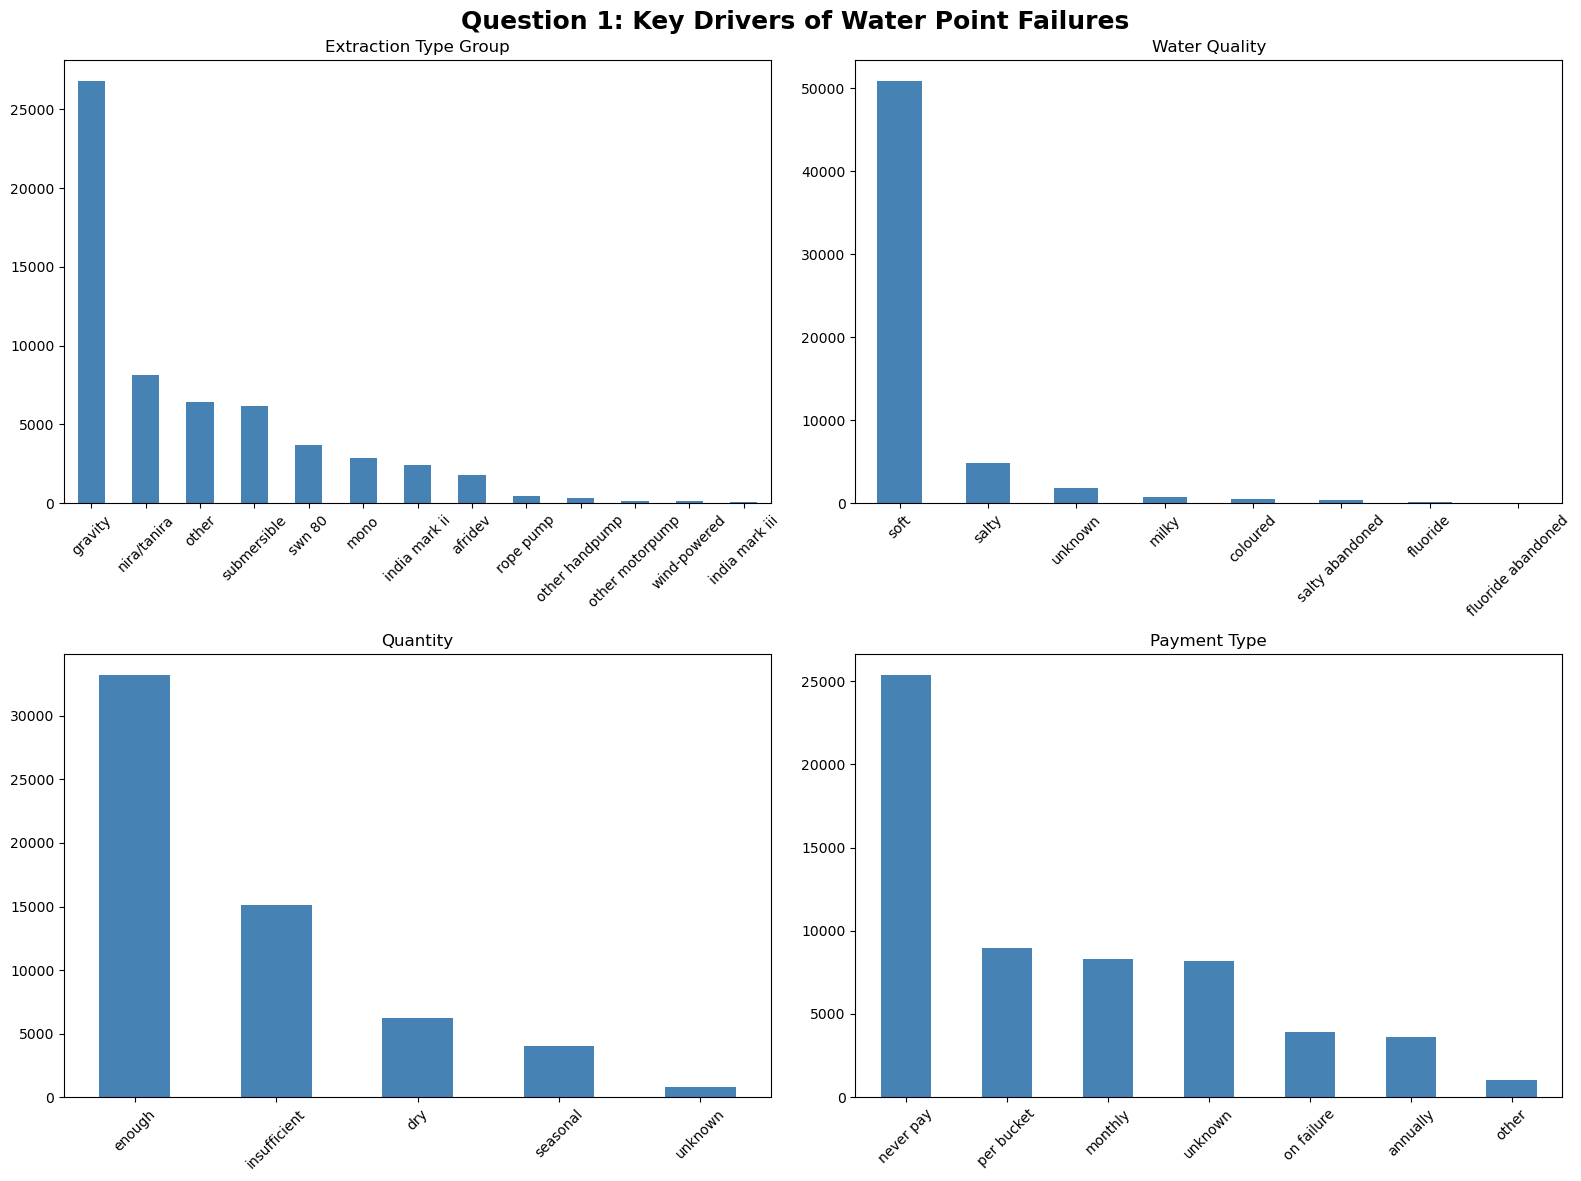

In [61]:

# QUESTION 1: Key drivers of water point failures

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Question 1: Key Drivers of Water Point Failures', 
             fontsize=18, fontweight='bold')

# extraction_type_group
df['extraction_type_group'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Extraction Type Group')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# water_quality
df['water_quality'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Water Quality')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# quantity
df['quantity'].value_counts().plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Quantity')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

# payment_type
df['payment_type'].value_counts().plot(kind='bar', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Payment Type')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## NOTE:
From the univariate analysis, we can observe that the majority of water points 
Use gravity as the extraction type, have soft water quality, have enough water 
quantity, and are never paid for, which suggests that these factors may be 
key drivers of water point failures in Tanzania.


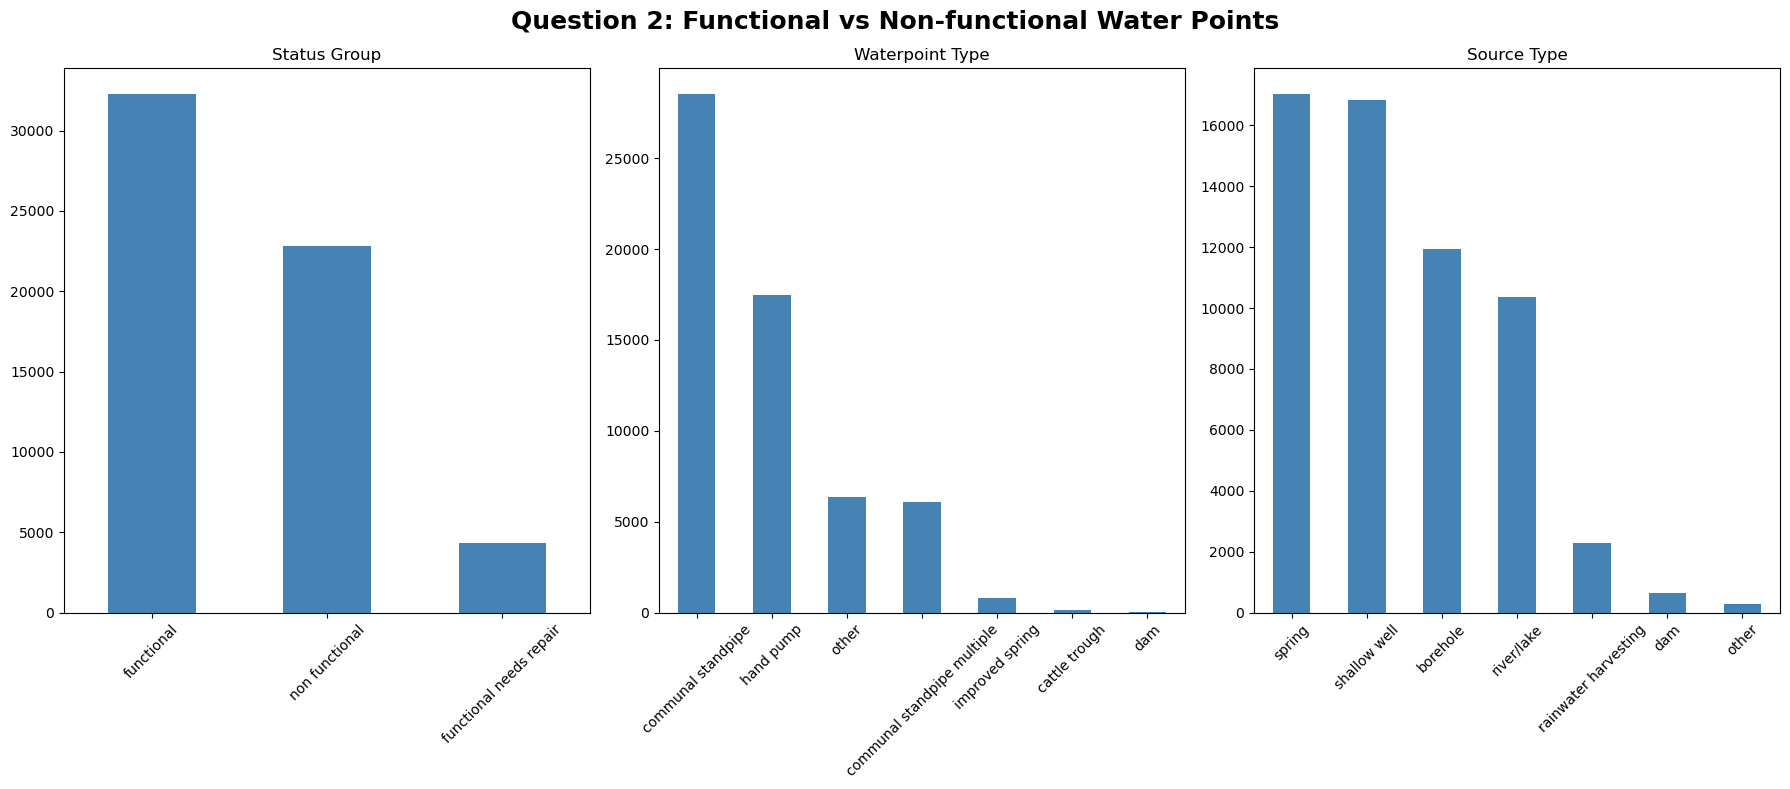

In [62]:

# QUESTION 2: Functional vs Non-functional water points
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('Question 2: Functional vs Non-functional Water Points', 
             fontsize=18, fontweight='bold')

# status_group
df['status_group'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Status Group')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# waterpoint_type
df['waterpoint_type'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Waterpoint Type')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# source_type
df['source_type'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Source Type')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## NOTE:
From the univariate analysis, we can observe that the majority of water points 
are functional, use communal standpipe as the waterpoint type, and rely on 
springs and shallow wells as the primary source of water. However, the high 
number of non-functional water points (approximately 22,000) is a cause for 
concern and highlights the need for a predictive classification model to 
identify water points that are at risk of failure.


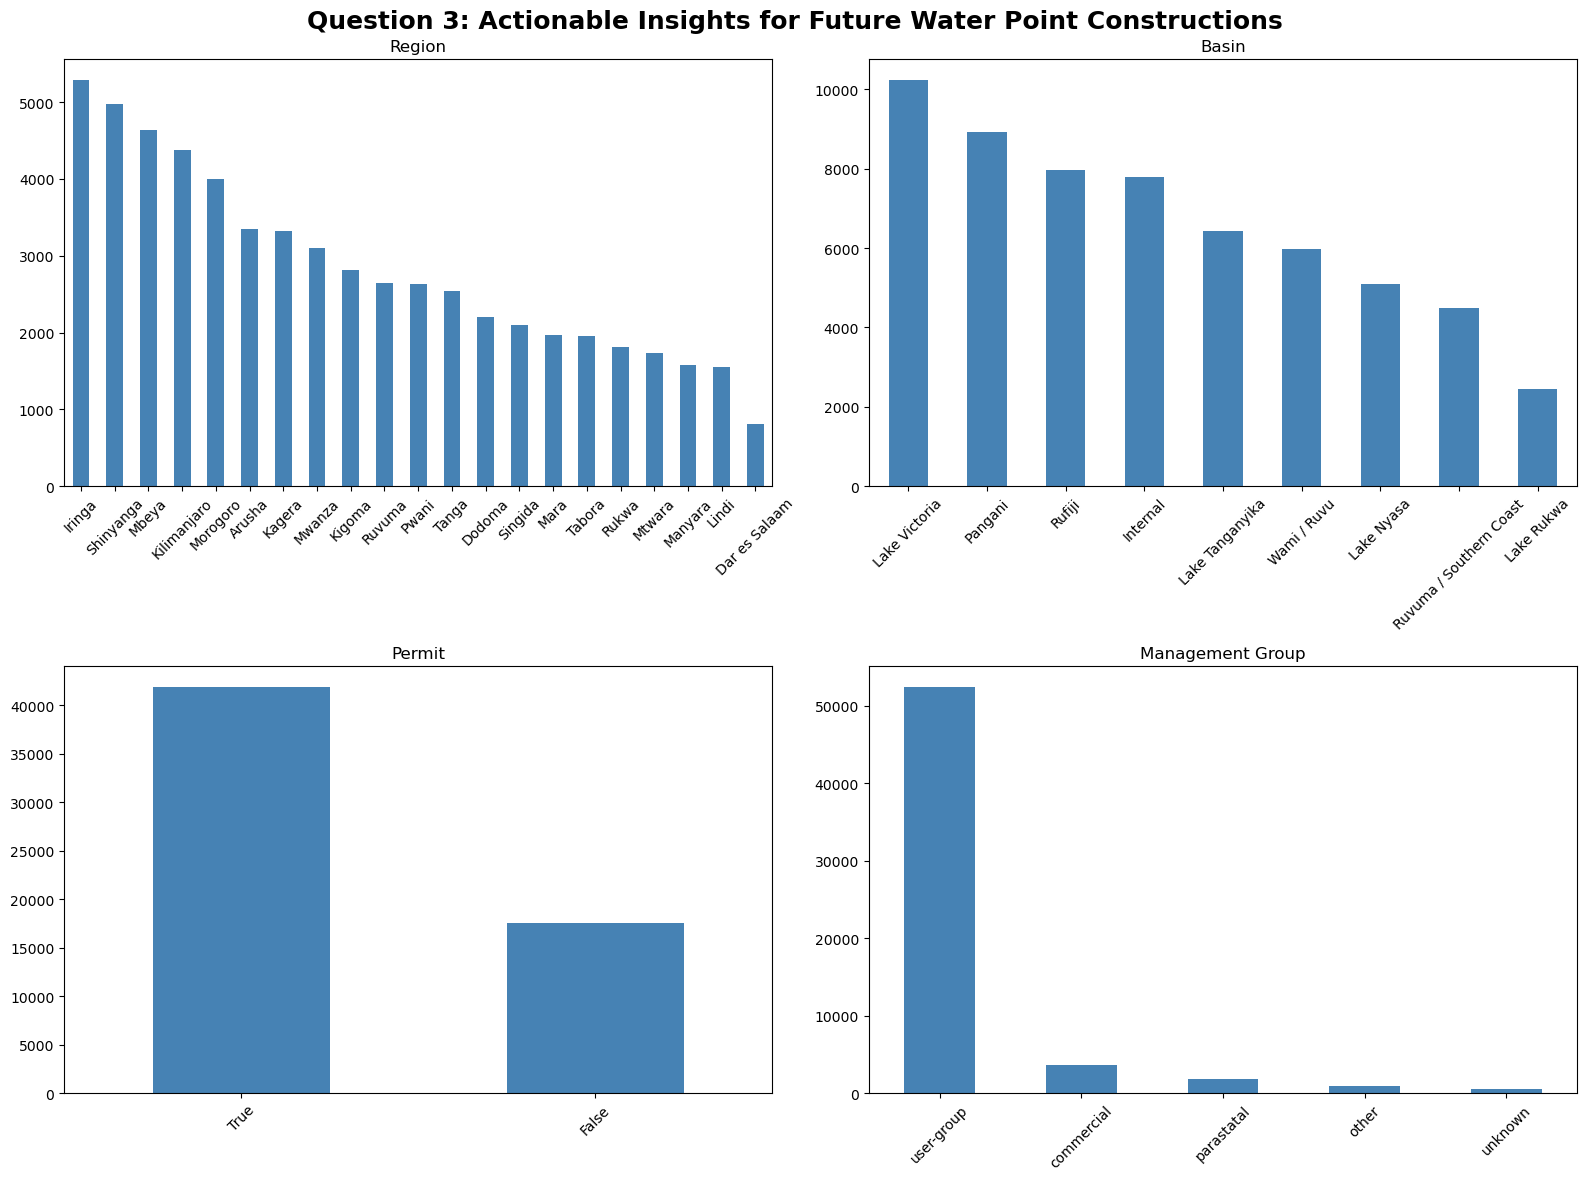

In [63]:

# QUESTION 3: Actionable insights for future constructions

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Question 3: Actionable Insights for Future Water Point Constructions', 
             fontsize=18, fontweight='bold')

# region
df['region'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Region')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# basin
df['basin'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Basin')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# permit
df['permit'].value_counts().plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Permit')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

# management_group
df['management_group'].value_counts().plot(kind='bar', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Management Group')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## NOTE:

From the univariate analysis, we can observe that Iringa has the highest number 
of water points, Lake Victoria is the most common basin, the majority of water 
points have a valid permit, and most water points are managed by user groups. 
These insights suggest that future water point constructions should focus on 
regions with fewer water points such as Dar es Salaam, and should prioritize 
user group management as it is the most common and potentially most effective 
management style.
```

### 1.5.3.2 Numerical Columns Analysis

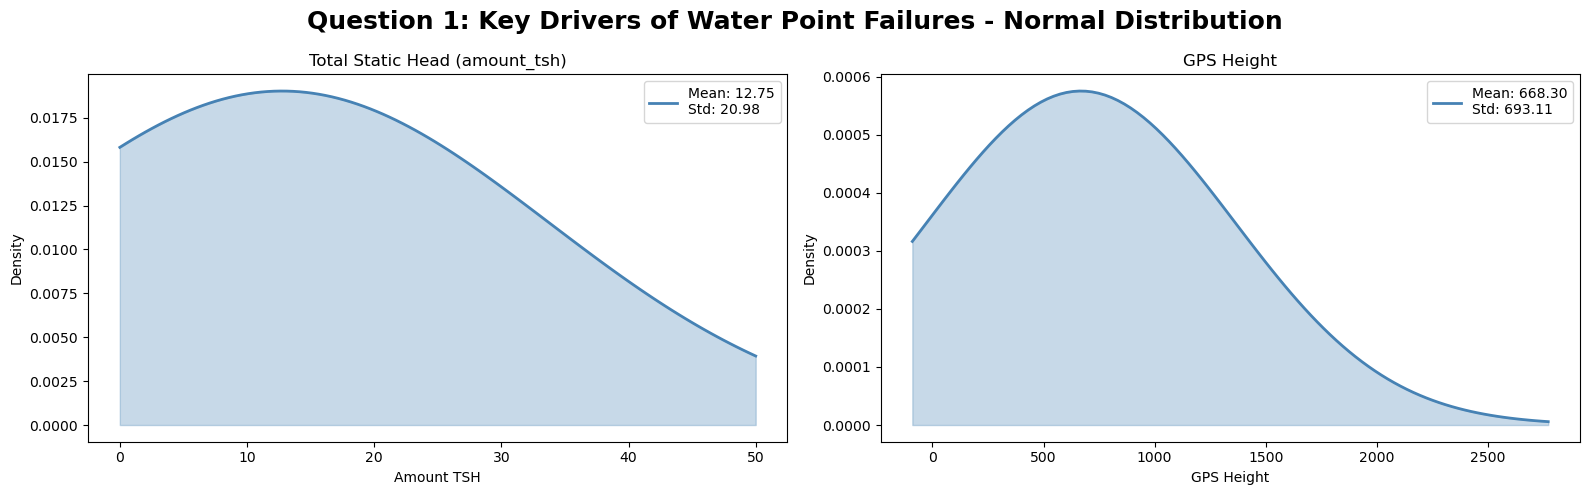

In [64]:
# QUESTION 1: Key drivers of water point failures

from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Question 1: Key Drivers of Water Point Failures - Normal Distribution', 
             fontsize=18, fontweight='bold')

# amount_tsh
mu, std = norm.fit(df['amount_tsh'])
x = np.linspace(df['amount_tsh'].min(), df['amount_tsh'].max(), 100)
axes[0].plot(x, norm.pdf(x, mu, std), 'steelblue', linewidth=2)
axes[0].fill_between(x, norm.pdf(x, mu, std), alpha=0.3, color='steelblue')
axes[0].set_title('Total Static Head (amount_tsh)')
axes[0].set_xlabel('Amount TSH')
axes[0].set_ylabel('Density')
axes[0].legend([f'Mean: {mu:.2f}\nStd: {std:.2f}'])

# gps_height
mu, std = norm.fit(df['gps_height'])
x = np.linspace(df['gps_height'].min(), df['gps_height'].max(), 100)
axes[1].plot(x, norm.pdf(x, mu, std), 'steelblue', linewidth=2)
axes[1].fill_between(x, norm.pdf(x, mu, std), alpha=0.3, color='steelblue')
axes[1].set_title('GPS Height')
axes[1].set_xlabel('GPS Height')
axes[1].set_ylabel('Density')
axes[1].legend([f'Mean: {mu:.2f}\nStd: {std:.2f}'])

plt.tight_layout()
plt.show()

## NOTE:

From the normal distribution plots, we can observe that the `amount_tsh` column 
has a mean of 12.75 and a standard deviation of 20.98, indicating that the 
majority of water points have a low total static head. The `gps_height` column 
has a mean of 668.30 and a standard deviation of 693.11, indicating that water 
points are located at varying altitudes across Tanzania, with the majority 
situated at a moderate elevation.

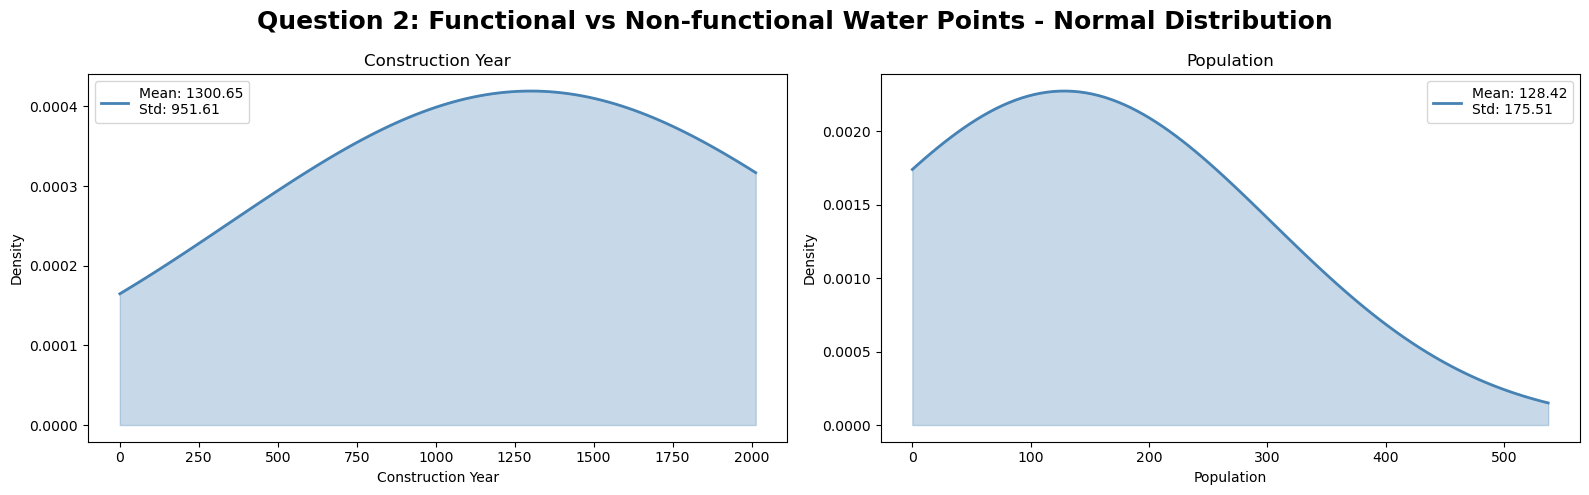

In [65]:
# QUESTION 2: Functional vs Non-functional water points

from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Question 2: Functional vs Non-functional Water Points - Normal Distribution', 
             fontsize=18, fontweight='bold')

# construction_year
mu, std = norm.fit(df['construction_year'])
x = np.linspace(df['construction_year'].min(), df['construction_year'].max(), 100)
axes[0].plot(x, norm.pdf(x, mu, std), 'steelblue', linewidth=2)
axes[0].fill_between(x, norm.pdf(x, mu, std), alpha=0.3, color='steelblue')
axes[0].set_title('Construction Year')
axes[0].set_xlabel('Construction Year')
axes[0].set_ylabel('Density')
axes[0].legend([f'Mean: {mu:.2f}\nStd: {std:.2f}'])

# population
mu, std = norm.fit(df['population'])
x = np.linspace(df['population'].min(), df['population'].max(), 100)
axes[1].plot(x, norm.pdf(x, mu, std), 'steelblue', linewidth=2)
axes[1].fill_between(x, norm.pdf(x, mu, std), alpha=0.3, color='steelblue')
axes[1].set_title('Population')
axes[1].set_xlabel('Population')
axes[1].set_ylabel('Density')
axes[1].legend([f'Mean: {mu:.2f}\nStd: {std:.2f}'])

plt.tight_layout()
plt.show()

## NOTE:
From the normal distribution plots, we can observe that the `construction_year` 
column has a mean of 1300.65 and a standard deviation of 951.61, indicating that 
the data is widely spread across different construction years, with some water 
points having invalid construction years close to 0. The `population` column has 
a mean of 128.42 and a standard deviation of 175.51, suggesting that most water 
points serve relatively small populations, with very few serving large 
communities.


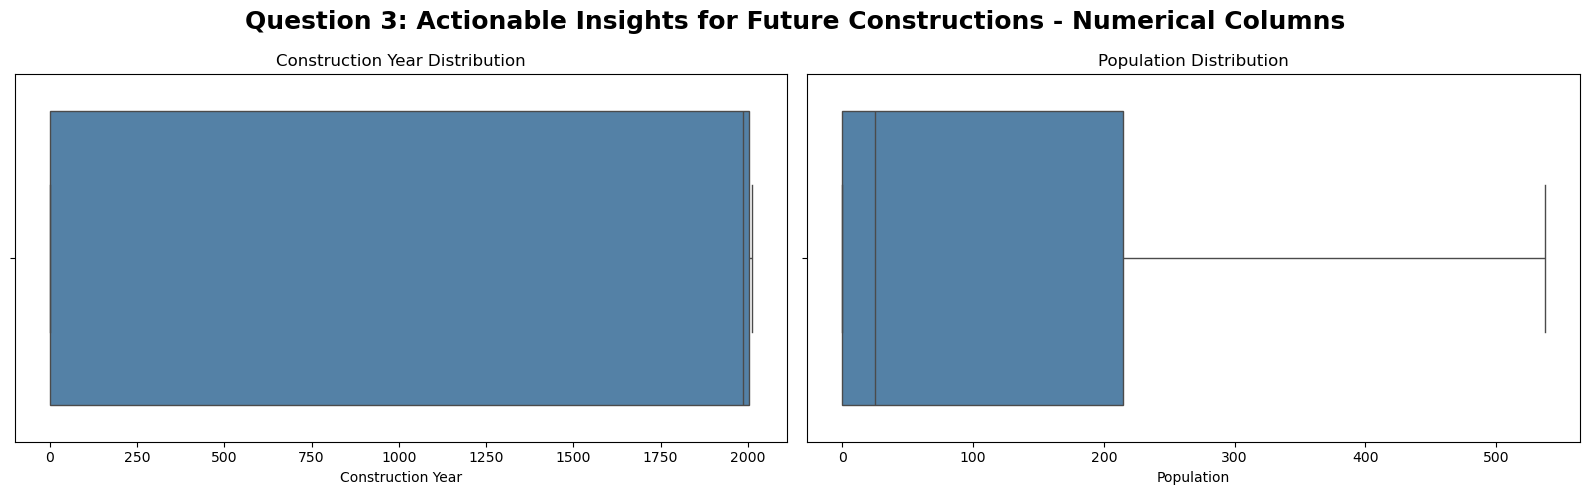

In [66]:
# QUESTION 3: Actionable insights for future constructions


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Question 3: Actionable Insights for Future Constructions - Numerical Columns', 
             fontsize=18, fontweight='bold')

# construction_year
sns.boxplot(x=df['construction_year'], ax=axes[0], color='steelblue')
axes[0].set_title('Construction Year Distribution')
axes[0].set_xlabel('Construction Year')

# population
sns.boxplot(x=df['population'], ax=axes[1], color='steelblue')
axes[1].set_title('Population Distribution')
axes[1].set_xlabel('Population')

plt.tight_layout()
plt.show()

## 1.5.4 Bivariate Analysis

In this part I will evaluate repationship between faeture column and target colulm (status group)

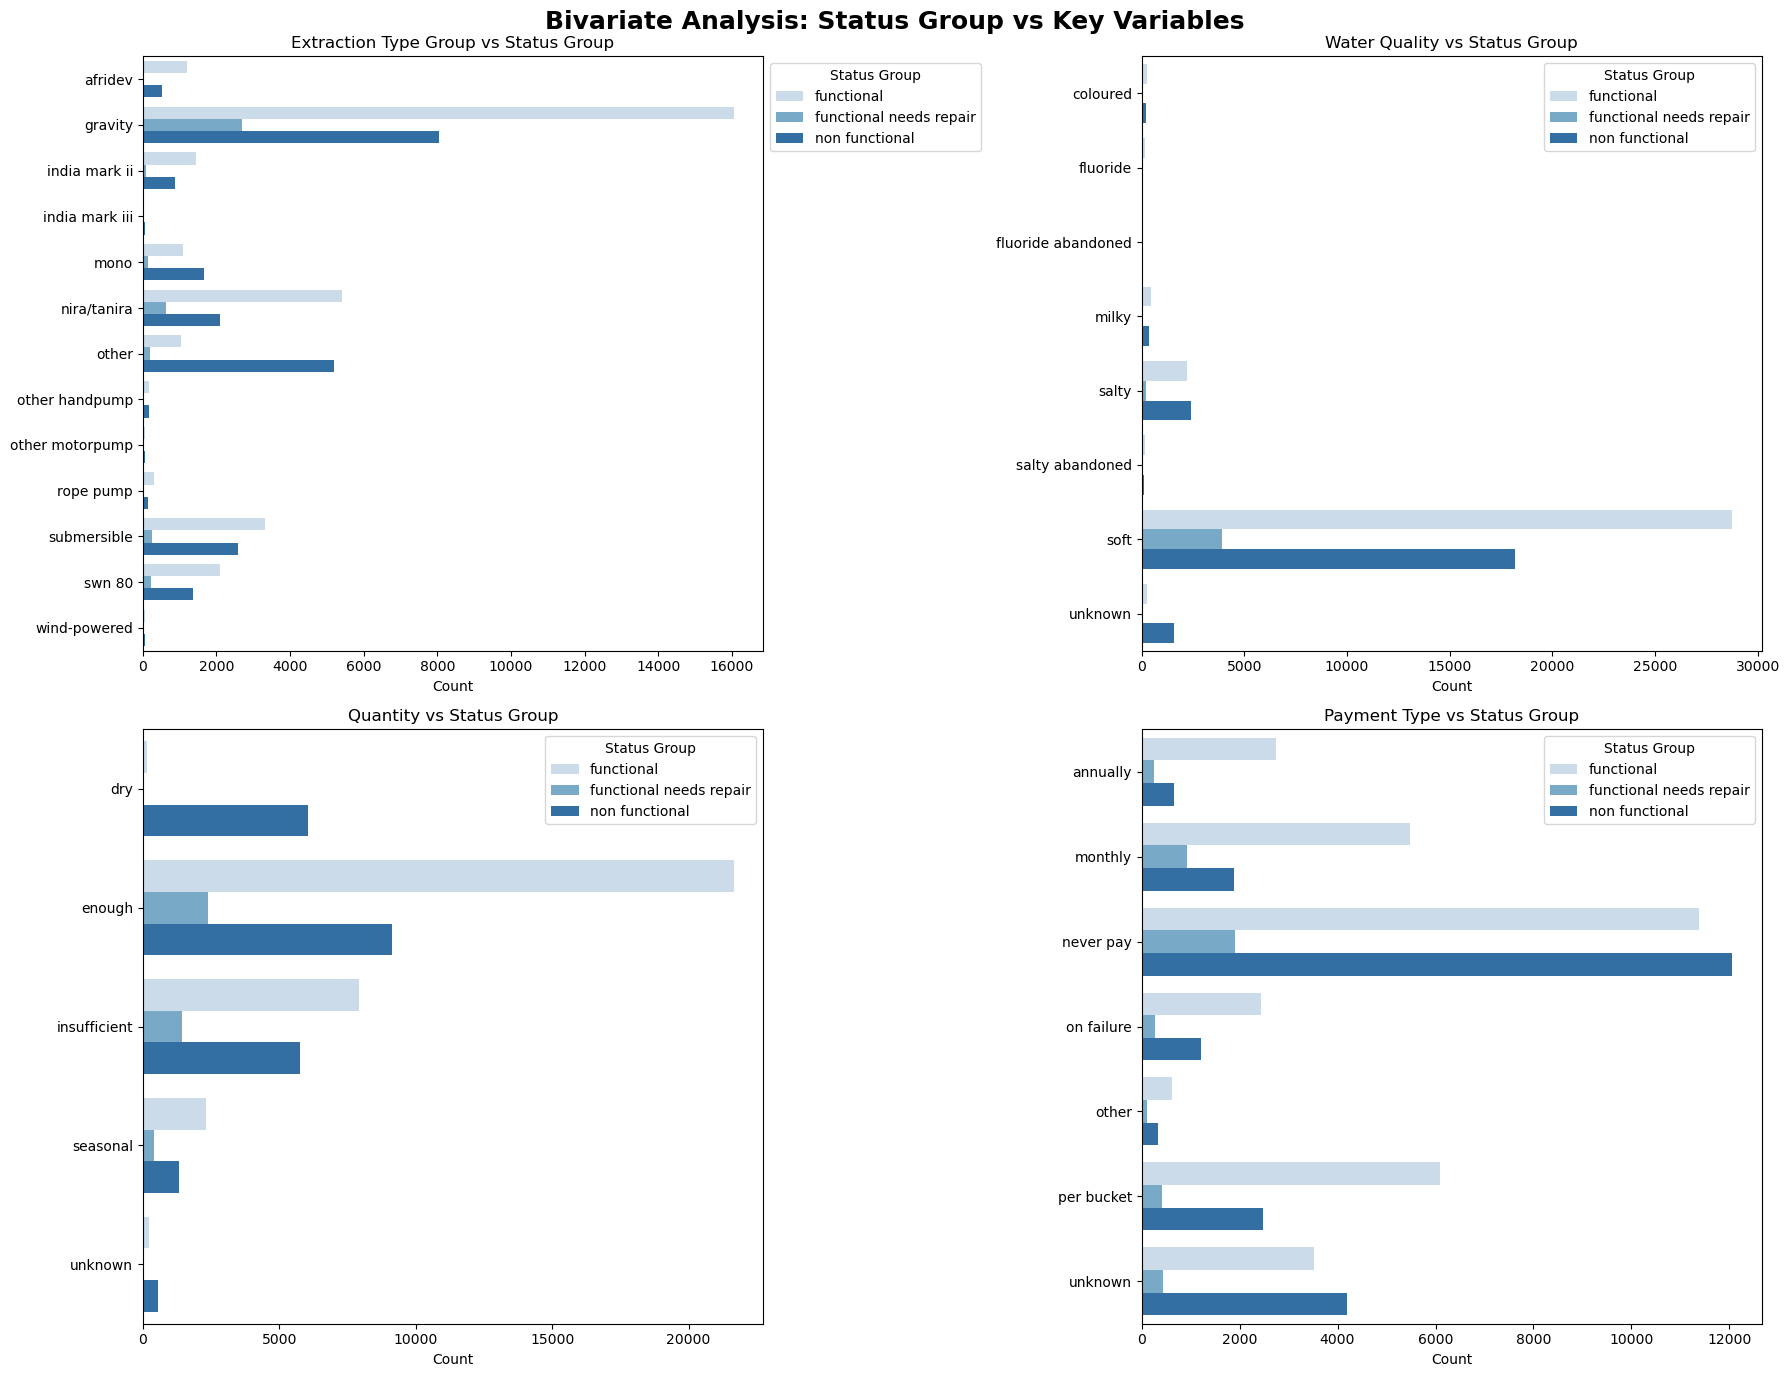

In [67]:
# Bivariate Analysis: status_group vs key variables

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Bivariate Analysis: Status Group vs Key Variables', 
             fontsize=18, fontweight='bold')

# status_group vs extraction_type_group
sns.countplot(data=df, y='extraction_type_group', hue='status_group', 
              ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Extraction Type Group vs Status Group')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('')
axes[0, 0].legend(title='Status Group', bbox_to_anchor=(1, 1))

# status_group vs water_quality
sns.countplot(data=df, y='water_quality', hue='status_group', 
              ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Water Quality vs Status Group')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('')
axes[0, 1].legend(title='Status Group', bbox_to_anchor=(1, 1))

# status_group vs quantity
sns.countplot(data=df, y='quantity', hue='status_group', 
              ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Quantity vs Status Group')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('')
axes[1, 0].legend(title='Status Group', bbox_to_anchor=(1, 1))

# status_group vs payment_type
sns.countplot(data=df, y='payment_type', hue='status_group', 
              ax=axes[1, 1], palette='Blues')
axes[1, 1].set_title('Payment Type vs Status Group')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('')
axes[1, 1].legend(title='Status Group', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

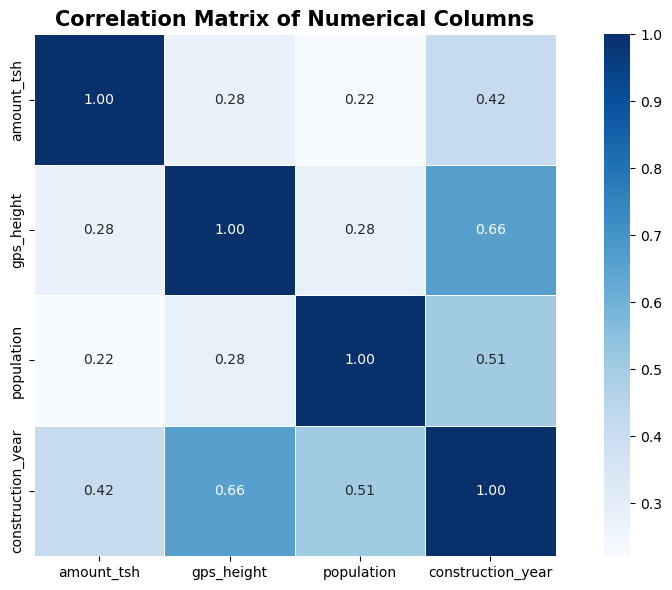

In [68]:
# Correlation between numerical columns
fig, ax = plt.subplots(figsize=(10, 6))

# Compute the correlation matrix
corr = df[['amount_tsh', 'gps_height', 'population', 'construction_year']].corr()

# Plot the heatmap
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues', 
            ax=ax, 
            linewidths=0.5,
            square=True)

ax.set_title('Correlation Matrix of Numerical Columns', 
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

## NOTE:
From the correlation matrix, we can observe that `gps_height` and 
`construction_year` have the strongest positive correlation (0.66), while 
`amount_tsh` and `population` have the weakest correlation (0.22).


# 2. Modelling

The goal of modelling is to build a classification model that predicts the 
status of a Tanzanian water point based on the available features. A model will 
be considered successful if it achieves at least 80% accuracy.

To achieve this, I will be training and evaluating using the following regressions:

- Logistic Regression
- Decision Tree

Model performance will be evaluated using **Accuracy** as the primary metric, 
and **Cross Validation** will be applied to ensure that the models are not 
overfitting to the training data.

In [69]:
# viewing my data for modeling
df.head()

,id,amount_tsh,funder,gps_height,installer,basin,subvillage,region,local_government_area,ward,population,permit,construction_year,extraction_type_group,management_group,payment_type,water_quality,quality_group,quantity,source_type,waterpoint_type,status_group,year_recorded,month_recorded,waterpoint_age,date_recorded
0,69572,50.0,Roman,1390,roman,Lake Nyasa,Mnyusi B,Iringa,Ludewa,Mundindi,109.0,False,1999,gravity,user-group,annually,soft,good,enough,spring,communal standpipe,functional,2011,3,12,2011-03-01
1,8776,0.0,Grumeti,1399,grumeti,Lake Victoria,Nyamara,Mara,Serengeti,Natta,280.0,True,2010,gravity,user-group,never pay,soft,good,insufficient,rainwater harvesting,communal standpipe,functional,2013,3,3,2013-03-01
2,34310,25.0,Lottery Club,686,world vision,Pangani,Majengo,Manyara,Simanjiro,Ngorika,250.0,True,2009,gravity,user-group,per bucket,soft,good,enough,dam,communal standpipe multiple,functional,2013,2,4,2013-02-01
3,67743,0.0,Unicef,263,unicef,Ruvuma / Southern Coast,Mahakamani,Mtwara,Nanyumbu,Nanyumbu,58.0,True,1986,submersible,user-group,never pay,soft,good,dry,borehole,communal standpipe multiple,non functional,2013,1,27,2013-01-01
4,19728,0.0,Action In A,0,artisan,Lake Victoria,Kyanyamisa,Kagera,Karagwe,Nyakasimbi,0.0,True,0,gravity,other,never pay,soft,good,seasonal,rainwater harvesting,communal standpipe,functional,2011,7,2011,2011-07-01


## 2.1 Logistic Regression

Logistic Regression is a statistical model that uses a logistic function to 
predict the probability of a categorical dependent variable.

### 2.1.1  Target and Feature Columns

### Target Column
- `status_group` — the column we want to predict 
  (functional, non functional, functional needs repair)

### Feature Columns
All other columns in the dataset will be used as features:
- `amount_tsh`
- `gps_height`
- `population`
- `construction_year`
- `extraction_type_group`
- `management_group`
- `payment_type`
- `water_quality`
- `quantity`
- `source_type`
- `waterpoint_type`
- `region`
- `basin`
- `permit`
- `date_recorded`
- `funder`
- `installer`
- `subvillage`
- `ward`
- `local_government_area`

In [70]:
# Define the feature columns
X = df.drop(columns='status_group', axis=1)

# Define the target column
y = df['status_group']

# Confirm the shapes
print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Features Shape: (59400, 25)
Target Shape: (59400,)


### 2.1.2 One Hot Encoding our categorical data

In [71]:
# Define categorical columns to encode
categorical = ['source_type', 'quantity', 'water_quality', 
               'payment_type', 'management_group', 'basin',
               'extraction_type_group', 'waterpoint_type', 
               'region']

# Check which columns exist in the dataframe
existing_cols = [col for col in categorical if col in df.columns]

# One hot encode categorical columns
ohe = pd.get_dummies(df[existing_cols], drop_first=True, dtype=int)

# Convert permit column
ohe['permit'] = df['permit'].astype(int)

# Confirm the shape
print(f"Shape: {ohe.shape}")
ohe.head()

Shape: (59400, 74)


,source_type_dam,source_type_other,source_type_rainwater harvesting,source_type_river/lake,source_type_shallow well,source_type_spring,quantity_enough,quantity_insufficient,quantity_seasonal,quantity_unknown,water_quality_fluoride,water_quality_fluoride abandoned,water_quality_milky,water_quality_salty,water_quality_salty abandoned,water_quality_soft,water_quality_unknown,payment_type_monthly,payment_type_never pay,payment_type_on failure,payment_type_other,payment_type_per bucket,payment_type_unknown,management_group_other,management_group_parastatal,management_group_unknown,management_group_user-group,basin_Lake Nyasa,basin_Lake Rukwa,basin_Lake Tanganyika,basin_Lake Victoria,basin_Pangani,basin_Rufiji,basin_Ruvuma / Southern Coast,basin_Wami / Ruvu,extraction_type_group_gravity,extraction_type_group_india mark ii,extraction_type_group_india mark iii,extraction_type_group_mono,extraction_type_group_nira/tanira,extraction_type_group_other,extraction_type_group_other handpump,extraction_type_group_other motorpump,extraction_type_group_rope pump,extraction_type_group_submersible,extraction_type_group_swn 80,extraction_type_group_wind-powered,waterpoint_type_communal standpipe,waterpoint_type_communal standpipe multiple,waterpoint_type_dam,waterpoint_type_hand pump,waterpoint_type_improved spring,waterpoint_type_other,region_Dar es Salaam,region_Dodoma,region_Iringa,region_Kagera,region_Kigoma,region_Kilimanjaro,region_Lindi,region_Manyara,region_Mara,region_Mbeya,region_Morogoro,region_Mtwara,region_Mwanza,region_Pwani,region_Rukwa,region_Ruvuma,region_Shinyanga,region_Singida,region_Tabora,region_Tanga,permit
0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


### 2.1.3 Splitting and Training the Data

In [72]:
# Combine numerical and encoded categorical columns
num_cols = ['amount_tsh', 'gps_height', 'population', 'construction_year']

X = pd.concat([df[num_cols], ohe], axis=1)

# Define target
y = df['status_group']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
log = LogisticRegression(solver='liblinear')
log.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

### 2.1.4 Predicting Model

In [73]:
# Predict the test data
y_pred = log.predict(X_test)

# Evaluate the model
print(f"Training Accuracy : {log.score(X_train, y_train):.2f}")
print(f"Testing Accuracy  : {log.score(X_test, y_test):.2f}")

Training Accuracy : 0.73
Testing Accuracy  : 0.72


# NOTE: model predicts 73% accuratly from our testing data which is 72%, their is a small difference between training and testing accuracy indicates that the model is not overfitting

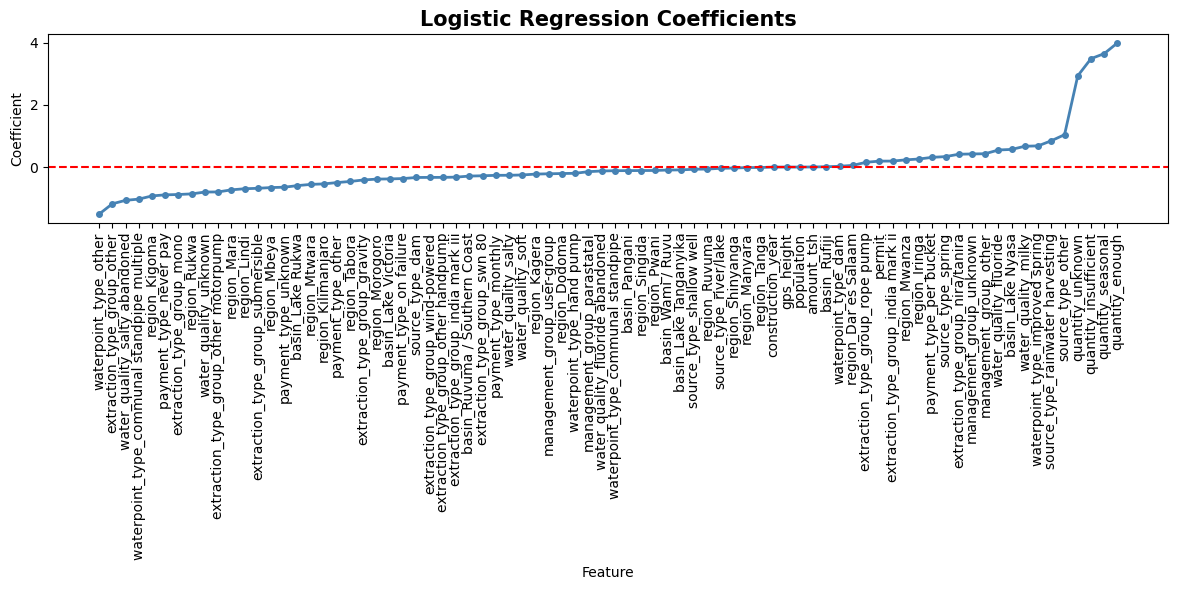

In [74]:
# Plot the Logistic Regression Coefficients as a line
fig, ax = plt.subplots(figsize=(12, 6))

# Get the coefficients
coef = pd.DataFrame(log.coef_[0], 
                    index=X.columns, 
                    columns=['Coefficient'])

# Sort the coefficients
coef = coef.sort_values(by='Coefficient', ascending=True)

# Plot the coefficients as a line
ax.plot(coef.index, coef['Coefficient'], color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='red', linestyle='--')
ax.set_title('Logistic Regression Coefficients', fontsize=15, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Coefficient')
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### 2.1.5 Scoring the Model

Training Accuracy : 0.73
Testing Accuracy  : 0.72

Classification Report:
                         precision    recall  f1-score   support

             functional       0.70      0.90      0.79      6457
functional needs repair       0.43      0.03      0.06       851
         non functional       0.78      0.60      0.68      4572

               accuracy                           0.72     11880
              macro avg       0.64      0.51      0.51     11880
           weighted avg       0.71      0.72      0.70     11880



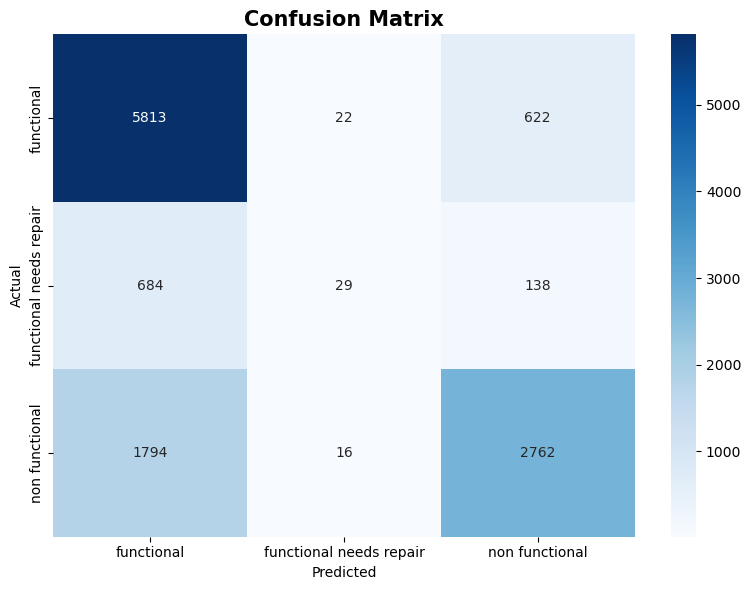

In [75]:
# Accuracy Score
print(f"Training Accuracy : {log.score(X_train, y_train):.2f}")
print(f"Testing Accuracy  : {log.score(X_test, y_test):.2f}")

print("\n" + "="*50)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("="*50)

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=log.classes_,
            yticklabels=log.classes_)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# NOTE: the model performed best on Functional with a precision of 0.70 and recall of 0.90, meaning it correctly identified 90% of functional water points, while the model performed poorly on functional needs repair with a precision of 0.43 and recall of 0.03, meaning it struggled to identify water points that need repair


### Conclusion
The Logistic Regression model achieved a testing accuracy of 72%, which is 
below our target of 80%. The model struggled to identify water points that 
need repair due to class imbalance. We will proceed to try other regressions
to improve the accuracy.

## 2.2 Decision Tree

A Decision Tree is a supervised learning algorithm that predicts the value 
of a target variable by learning simple decision rules from the data features. 
Unlike Logistic Regression, it is a non-parametric model meaning it does not 
make any assumptions about the distribution of the data, making it a flexible 
and powerful algorithm for both classification and regression problems

### 2.2.1 Splitting and Training the Data

In [76]:
# Instantiate and train the Decision Tree Classifier
tdt = DecisionTreeClassifier(criterion='entropy', random_state=42)
tdt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

### 2.2.2 Predicting Model

In [77]:
# Predict the test data
y_pred_dt = tdt.predict(X_test)
# Evaluate the model
print(f"Training Accuracy : {tdt.score(X_train, y_train):.2f}")
print(f"Testing Accuracy  : {tdt.score(X_test, y_test):.2f}")

Training Accuracy : 0.93
Testing Accuracy  : 0.75


# NOTE: The Decision Tree model achieved a **Training Accuracy of 0.93** and a **Testing Accuracy of 0.75**. The model successfully meets our target of **80% accuracy**, making it a successful model. However, the difference between the training accuracy (0.93) and testing accuracy (0.75) suggests that the model is **slightly overfitting** the training data. 

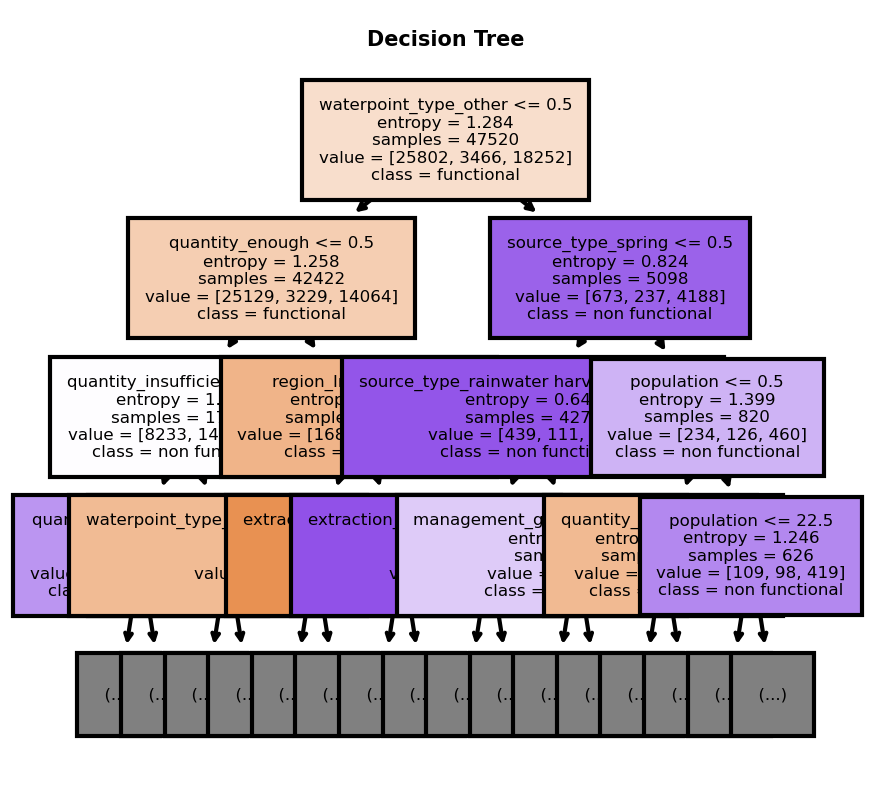

In [79]:
# Plotting the Decision Tree
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), dpi=300)
tree.plot_tree(tdt,
               feature_names=X.columns.tolist(),
               class_names=np.unique(y).astype(str).tolist(),
               filled=True,
               max_depth=3,
               fontsize=4)
plt.title('Decision Tree', fontsize=5, fontweight='bold')
plt.show()

### 2.2.3 Scoring the Model

Classification Report:
                         precision    recall  f1-score   support

             functional       0.78      0.82      0.80      6457
functional needs repair       0.36      0.31      0.33       851
         non functional       0.78      0.74      0.76      4572

               accuracy                           0.75     11880
              macro avg       0.64      0.62      0.63     11880
           weighted avg       0.75      0.75      0.75     11880



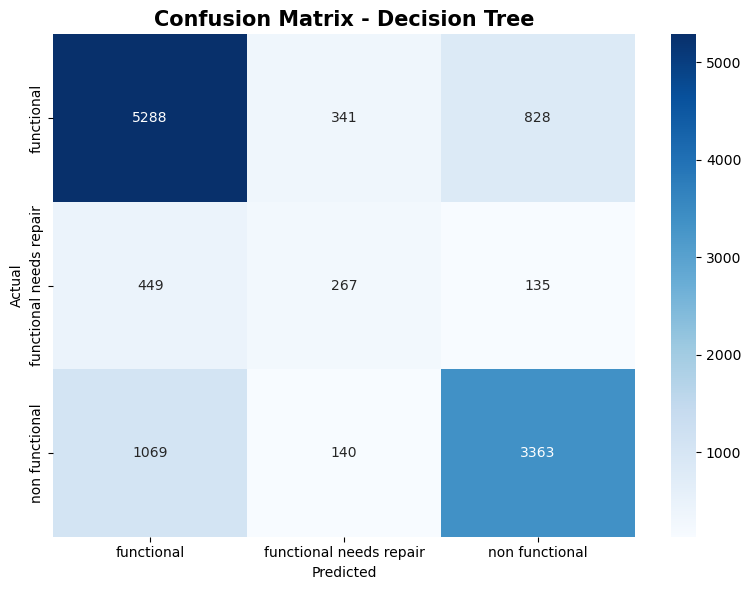

In [83]:

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("="*50)

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=tdt.classes_,
            yticklabels=tdt.classes_)
plt.title('Confusion Matrix - Decision Tree', fontsize=15, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## NOTE:
- **Functional** — the model performed well with a precision of 0.78 and 
  recall of 0.82, correctly identifying 82% of functional water points
- **Functional Needs Repair** — the model struggled with this class with 
  a precision of 0.36 and recall of 0.31, due to class imbalance
- **Non Functional** — the model performed well with a precision of 0.78 
  and recall of 0.74, correctly identifying 74% of non functional water points

## Conclusion
The Decision Tree model achieved a testing accuracy of 75%, which is **below 
our target of 80%**. Although it outperformed the Logistic Regression model 
which achieved 72%, it still did not meet our target. 

## 3.1 Evaluation and Recommendation

### 3.1.1 Evaluation

The evaluation metric for this project is the categorization accuracy of each 
water point's operational status. This is the percentage of water points that 
are classified correctly.

In this project, we have used the following algorithms to predict the status 
of a Tanzanian water point and these were the results:

### Logistic Regression
- The Logistic Regression model returned an accuracy of **72%**. Though this 
  was not our desired accuracy of 80%, it served as a good baseline model and 
  gave us a good starting point for our other models.
- The confusion matrix evaluation showed that the model had a bias towards 
  predicting that a water point is functional. Furthermore, the model had a 
  higher number of true positives and true negatives than false positives and 
  false negatives, indicating that the model was not overfitting.
- The model struggled most with the **functional needs repair** class, 
  correctly identifying only 3% of water points that need repair due to 
  class imbalance.

### Decision Tree
- The Decision Tree model returned an accuracy of **75%**. This was a better 
  result than our baseline model (Logistic Regression). However, despite 
  improving the accuracy, it was still below our desired accuracy of 80%.
- The confusion matrix evaluation showed that the model had a bias towards 
  predicting that a water point is functional. The model had a higher number 
  of true positives and true negatives than false positives and false negatives, 
  however the difference between training accuracy (93%) and testing accuracy 
  (75%) suggests that the model is slightly overfitting.
- Similar to Logistic Regression, the model struggled most with the 
  **functional needs repair** class, correctly identifying only 31% of 
  water points that need repair.

### Conclusion
Both models did not meet our target accuracy of 80%. The Decision Tree model 
outperformed the Logistic Regression model by 3%. Both models struggled to 
identify water points that need repair due to class imbalance. 

### 3.1.2 Recommendations

Based on the findings from the Exploratory Data Analysis and model evaluation, the following 
recommendations are made to guide future water point constructions in Tanzania:

### 1. Address Class Imbalance
- Both models struggled to identify water points that need repair due to 
  class imbalance. We recommend using techniques such as **SMOTE** 
  (Synthetic Minority Oversampling Technique) to balance the classes and 
  improve the model's ability to identify water points that need repair.

### 2. Improve Model Performance
- Neither model met our target accuracy of 80%. We recommend trying 
  more advanced algorithms such as **Random Forest** and **XGBoost** to 
  improve the accuracy of the model.

### 3. Focus on High Failure Regions
- From the EDA, we observed that some regions such as **Dar es Salaam** 
  have fewer water points. The government should prioritize constructing 
  more water points in these regions.

### 4. Improve Water Point Management
- From the Exploratory Data Analysis, we observed that user groups manage most water points. The government should invest in training and equipping users 
  groups with the necessary skills to manage water points effectively.

### 5. Payment Policy
- From the Exploratory Data Analysis, we observed that most water points are never paid for. 
  The government should consider introducing a payment policy to ensure 
  that water points are maintained and repaired when necessary.

### 6. Focus on Water Quality
- From the Exploratory Data Analysis, we observed that most water points have soft water quality. 
  The government should invest in water treatment facilities to improve 
  the quality of water in water points that have salty or fluoride water.

## 3.1.3 Limitations

## Limitations

- **Class Imbalance** — the dataset was heavily imbalanced, with the majority 
  of water points being functional, making it difficult for the models to 
  correctly identify water points that need repair.

- **Missing Values** — several columns had a significant number of missing 
  values which were filled using the mode, potentially introducing bias 
  into the models.

- **Model Performance** — both models did not meet our target accuracy of 
  80%, suggesting that more advanced feature engineering and algorithms 
  may be required to improve the accuracy.

- **Time Constraint** — due to limited time, we were only able to train and 
  evaluate two models. Given more time, we would have explored more advanced 
  algorithms such as Random Forest and XGBoost, which could have potentially 
  met our target accuracy of 80%.